<a href="https://colab.research.google.com/github/DeemonDuck/upi-sentinel/blob/main/03_hybrid_cnn_bilstm_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UPI Sentinel – Hybrid CNN + BiLSTM + Attention Model
Sliding Window Sequence Modeling with SMOTE Balancing


## 1. Environment Setup & Reproducibility


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)


## 2. Required Libraries


In [ ]:
from collections import Counter

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

from tensorflow.keras import layers, Model, Input, backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from collections import Counter



## 3. Data Loading


In [ ]:
# Load PaySim dataset
df = pd.read_csv("data/paysim.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 4. Basic Preprocessing


In [ ]:
# Required columns
required_cols = [
    'step',
    'type',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'isFraud'
]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Column {col} missing from dataset.")

# Keep only required columns
df = df[required_cols].copy()

# Encode transaction type
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'].astype(str))

# Handle missing values
num_cols = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

df[num_cols] = df[num_cols].fillna(0.0)

# Feature scaling
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Preprocessing complete.")
print("Data shape:", df.shape)


Preprocessing complete.
Data shape: (6362620, 8)


**Observations:**

- The dataset has been restricted to core transactional and balance-related features.
- Categorical transaction type has been encoded numerically.
- Numerical features have been standardized to improve neural network convergence.
- Previously engineered rule-based features (such as exact balance-matching indicators) were intentionally excluded in this version to prevent deterministic behavior and potential leakage-like patterns.
- This ensures that the model must learn fraud patterns from transactional dynamics rather than relying on near-explicit fraud signals.


## 5. Global Sliding Window Sequence Generation


Transactions are sorted by global time (`step`) and overlapping sliding windows are created.  
Each sequence is labeled based on the fraud status of the final transaction in the window.


In [ ]:
df = df.sort_values('step').reset_index(drop=True)

feature_cols = ['type','amount','oldbalanceOrg',
                'newbalanceOrig','oldbalanceDest','newbalanceDest']

label_col = 'isFraud'

seq_len = 5
stride = 1

os.makedirs("data/cache", exist_ok=True)

X_path = "data/cache/X_seq_len5.npy"
y_path = "data/cache/y_seq_len5.npy"


if os.path.exists(X_path) and os.path.exists(y_path):
    print("Loading cached sequences...")
    X = np.load(X_path)
    y = np.load(y_path)
else:
    print("Generating sequences (no cache found)...")

    X_seq = []
    y_seq = []

    rows = df.shape[0]

    for start in tqdm(range(0, rows - seq_len + 1, stride), desc="Generating sequences"):
        window = df.iloc[start:start + seq_len]
        X_seq.append(window[feature_cols].values)
        y_seq.append(int(window[label_col].iloc[-1]))

    X = np.array(X_seq, dtype=np.float32)
    y = np.array(y_seq, dtype=np.int32)

    np.save(X_path, X)
    np.save(y_path, y)

    print("Sequences generated and cached.")

print("Sequence shape:", X.shape)
print("Label distribution:", Counter(y))


Generating sequences (no cache found)...


Generating sequences: 100%|██████████| 6362616/6362616 [1:08:46<00:00, 1541.88it/s]


Sequences generated and cached.
Sequence shape: (6362616, 5, 6)
Label distribution: Counter({np.int32(0): 6354403, np.int32(1): 8213})


**Observations:**

- Sliding window sequences of length 5 were generated across globally ordered transactions.
- Each sequence captures short-term transactional dynamics.
- Labels are assigned based on the final transaction within each window.
- The resulting dataset is now 3D: (samples, timesteps, features), suitable for hybrid temporal modeling.


## 6. Train-Test Split


The dataset is split using stratified sampling to preserve fraud distribution in both training and testing sets.  
SMOTE will be applied only to the training set to prevent data leakage.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (5090092, 5, 6)
Testing shape: (1272524, 5, 6)


**Observations:**

- The dataset has been split into 80% training and 20% testing data.
- Stratified sampling ensures that the class imbalance ratio remains consistent across both sets.
- The resulting tensors retain 3D structure: (samples, timesteps, features).
- SMOTE will be applied only to the training set to maintain a realistic evaluation on unseen data.


## 7. SMOTE Oversampling (Training Set Only)


Since SMOTE operates on 2D feature space, the 3D sequence tensors are temporarily flattened.  
After oversampling, the tensors are reshaped back to (samples, timesteps, features).


In [ ]:
# Extract sequence dimensions
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# Flatten sequences for SMOTE
X_train_flat = X_train.reshape((X_train.shape[0],
                                n_timesteps * n_features))

print("Before SMOTE:", Counter(y_train))

# Apply SMOTE only on training data
sm = SMOTE(random_state=SEED)
X_res_flat, y_res = sm.fit_resample(X_train_flat, y_train)

# Reshape back to 3D
X_res = X_res_flat.reshape((-1, n_timesteps, n_features))

print("After SMOTE:", Counter(y_res))
print("Resampled shape:", X_res.shape)


Before SMOTE: Counter({np.int32(0): 5083522, np.int32(1): 6570})
After SMOTE: Counter({np.int32(0): 5083522, np.int32(1): 5083522})
Resampled shape: (10167044, 5, 6)


**Observations:**

- The original training set was highly imbalanced, with only 6,570 fraud sequences compared to over 5 million non-fraud sequences.
- SMOTE synthetically oversampled the minority class to achieve perfect class balance.
- This increased the training dataset size to over 10 million sequences.
- While balancing improves minority representation, excessive synthetic generation may introduce interpolation artifacts and increase computational cost.


## 8. Custom Attention Mechanism


A trainable attention layer is implemented to allow the model to assign different importance weights to individual timesteps within each sequence.


In [ ]:
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        feature_dim = input_shape[-1]

        self.W = self.add_weight(
            name="W",
            shape=(feature_dim, feature_dim),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="b",
            shape=(feature_dim,),
            initializer="zeros",
            trainable=True
        )

        self.u = self.add_weight(
            name="u",
            shape=(feature_dim, 1),
            initializer="glorot_uniform",
            trainable=True
        )

        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs shape: (batch_size, timesteps, features)

        uit = K.tanh(K.dot(inputs, self.W) + self.b)
        ait = K.dot(uit, self.u)
        ait = K.squeeze(ait, axis=-1)
        a = K.softmax(ait)

        a_expanded = K.expand_dims(a, axis=-1)
        weighted_inputs = inputs * a_expanded

        output = K.sum(weighted_inputs, axis=1)

        return output

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[2])


**Observations:**

- The attention mechanism enables the model to dynamically weight different timesteps.
- Instead of treating all transactions equally, the model learns which parts of a sequence are most indicative of fraud.
- This enhances interpretability and improves temporal modeling capacity.


## 9. Hybrid CNN + BiLSTM + Attention Model


The model combines convolutional feature extraction, bidirectional temporal modeling, and an attention mechanism to capture short-term transaction dynamics and emphasize important timesteps.


In [ ]:
# Input dimensions
timesteps = n_timesteps
features = n_features

# Input layer
inp = Input(shape=(timesteps, features))

# 1D Convolution for local feature interactions
x = layers.Conv1D(
    filters=64,
    kernel_size=2,
    activation='relu',
    padding='same'
)(inp)

x = layers.Dropout(0.2)(x)

# Bidirectional LSTM for temporal modeling
x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=True)
)(x)

# Attention mechanism
att = AttentionLayer()(x)

# Dense layers for classification
x = layers.Dense(64, activation='relu')(att)
x = layers.Dropout(0.3)(x)

out = layers.Dense(1, activation='sigmoid')(x)

# Build model
model = Model(inputs=inp, outputs=out)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 5, 64)          │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 5, 128)         │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │        16,640 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,841 (358.75 KB)

 Trainable params: 91,841 (358.75 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Stratified Training Subset Selection


Due to the large number of synthetic sequences generated by SMOTE (~10M samples),
a stratified subset of the balanced training data is selected to ensure computational efficiency while preserving class balance.


In [ ]:
# Limit dataset size for stable training
subset_size = 100_000  # Adjust based on available memory

X_res_small, _, y_res_small, _ = train_test_split(
    X_res,
    y_res,
    train_size=subset_size,
    stratify=y_res,
    random_state=SEED
)

print("Training subset shape:", X_res_small.shape)
print("Class distribution:", Counter(y_res_small))


Training subset shape: (100000, 5, 6)
Class distribution: Counter({np.int32(1): 50000, np.int32(0): 50000})


**Observations:**

- The SMOTE-balanced dataset exceeded 10 million sequences.
- A stratified subset of 100,000 samples was selected to enable efficient training.
- Class balance (50–50) was preserved within the subset.
- This approach maintains synthetic diversity while reducing computational burden.





## 11. Model Training Configuration


In [ ]:
# Training configuration
EPOCHS = 10
BATCH_SIZE = 64

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

classes = np.unique(y_res_small)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_res_small
)

class_weights = dict(zip(classes, weights))
print("Class Weights:", class_weights)

# Train the model on the balanced subset
history = model.fit(
    X_res_small,
    y_res_small,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=2
)


Class Weights: {np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0)}
Epoch 1/10
1563/1563 - 104s - 67ms/step - accuracy: 0.9243 - loss: 0.1872 - precision: 0.9402 - recall: 0.9063 - val_accuracy: 0.9761 - val_loss: 0.0787 - val_precision: 0.0485 - val_recall: 0.9416
Epoch 2/10
1563/1563 - 95s - 61ms/step - accuracy: 0.9665 - loss: 0.0876 - precision: 0.9701 - recall: 0.9626 - val_accuracy: 0.9884 - val_loss: 0.0377 - val_precision: 0.0949 - val_recall: 0.9379
Epoch 3/10
1563/1563 - 95s - 61ms/step - accuracy: 0.9732 - loss: 0.0715 - precision: 0.9744 - recall: 0.9720 - val_accuracy: 0.9855 - val_loss: 0.0402 - val_precision: 0.0791 - val_recall: 0.9623
Epoch 4/10
1563/1563 - 142s - 91ms/step - accuracy: 0.9764 - loss: 0.0647 - precision: 0.9771 - recall: 0.9757 - val_accuracy: 0.9842 - val_loss: 0.0494 - val_precision: 0.0730 - val_recall: 0.9635
Epoch 5/10
1563/1563 - 95s - 61ms/step - accuracy: 0.9774 - loss: 0.0618 - precision: 0.9775 - recall: 0.9773 - val_accuracy: 0.9881 -

## 12. Training Curves


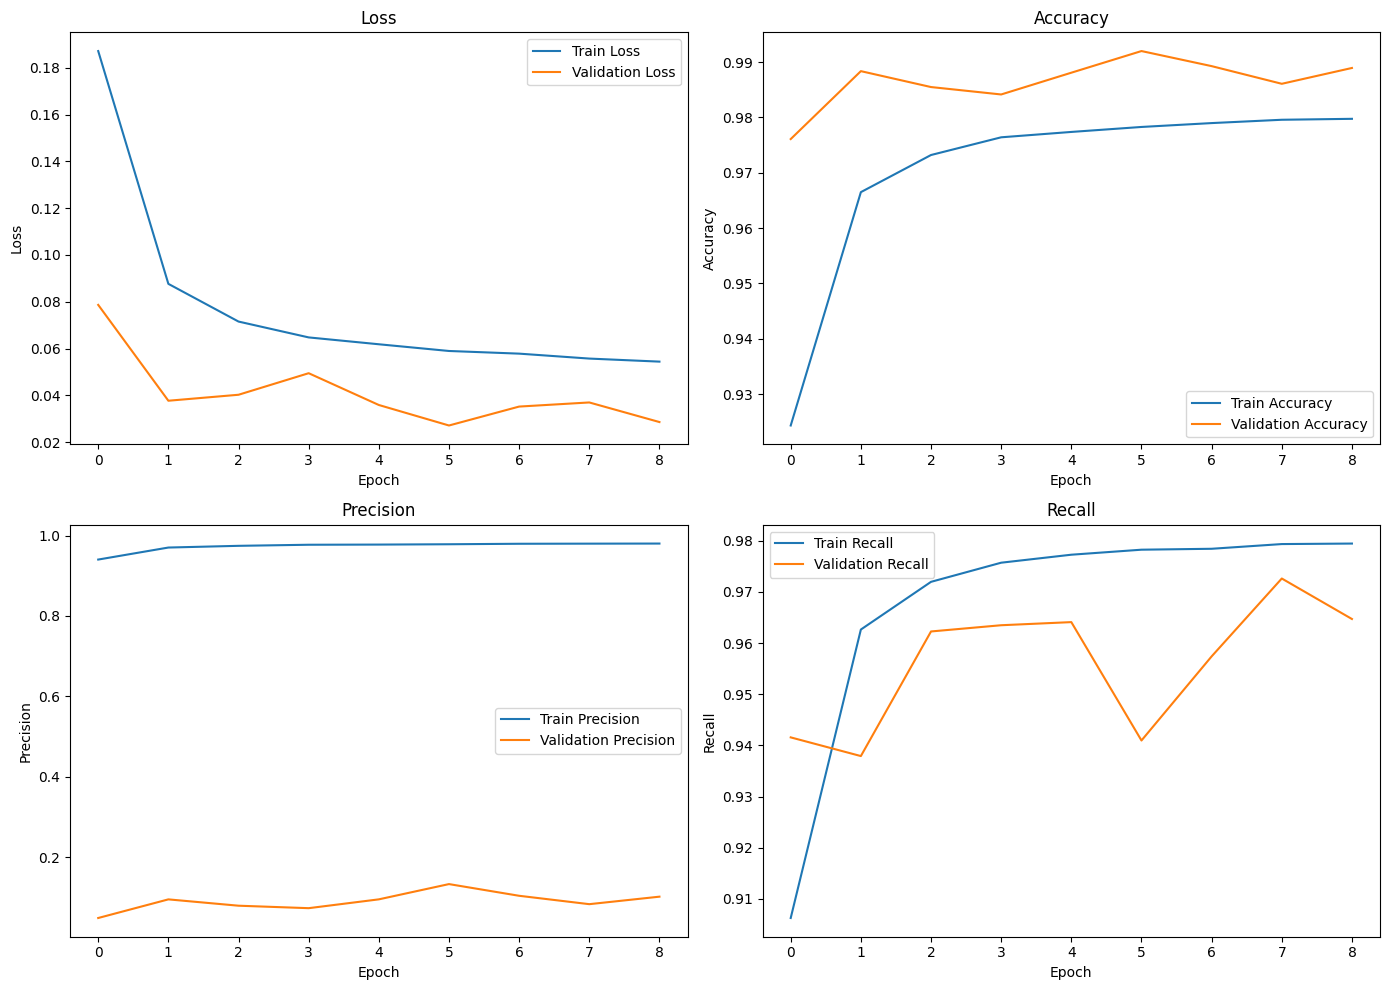

In [ ]:
# Extract training history
hist = history.history

plt.figure(figsize=(14, 10))

# ---- Loss ----
plt.subplot(2, 2, 1)
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# ---- Accuracy ----
plt.subplot(2, 2, 2)
plt.plot(hist["accuracy"], label="Train Accuracy")
plt.plot(hist["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ---- Precision ----
plt.subplot(2, 2, 3)
plt.plot(hist["precision"], label="Train Precision")
plt.plot(hist["val_precision"], label="Validation Precision")
plt.title("Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend()

# ---- Recall ----
plt.subplot(2, 2, 4)
plt.plot(hist["recall"], label="Train Recall")
plt.plot(hist["val_recall"], label="Validation Recall")
plt.title("Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()


## 13. Final Evaluation on Imbalanced Test Set


In [ ]:
# Evaluate on real-world imbalanced test data
test_metrics = model.evaluate(X_test, y_test, verbose=1)

print("\nTest Metrics:")
print(f"Loss      : {test_metrics[0]:.4f}")
print(f"Accuracy  : {test_metrics[1]:.4f}")
print(f"Precision : {test_metrics[2]:.4f}")
print(f"Recall    : {test_metrics[3]:.4f}")


39767/39767 ━━━━━━━━━━━━━━━━━━━━ 181s 5ms/step - accuracy: 0.9921 - loss: 0.0270 - precision: 0.1368 - recall: 0.9420

Test Metrics:
Loss      : 0.0271
Accuracy  : 0.9920
Precision : 0.1329
Recall    : 0.9410


## 14. Classification Report and Confusion Matrix

In [ ]:
# Ensure correct shapes
y_test = y_test.ravel()
y_pred_proba = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.13      0.94      0.23      1643

    accuracy                           0.99   1272524
   macro avg       0.57      0.97      0.61   1272524
weighted avg       1.00      0.99      0.99   1272524

Confusion Matrix:
[[1260793   10088]
 [     97    1546]]


In [ ]:
# Generate probability predictions
y_pred_proba = model.predict(X_test, verbose=0)

# Compute ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {auc:.4f}")


ROC-AUC Score: 0.9968


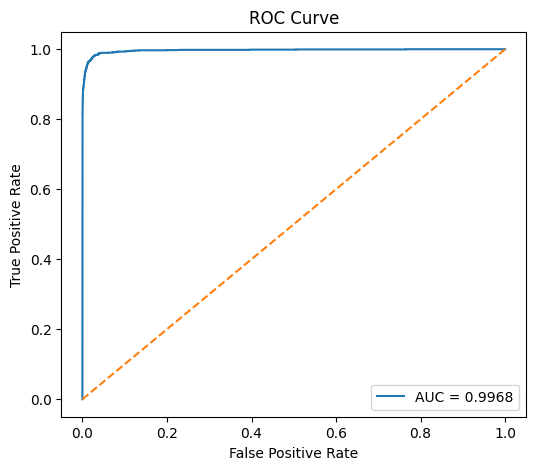

In [ ]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


##15. Threshold Optimization


In [ ]:
# Use already computed probabilities
# (reuse y_pred_proba from ROC section)

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Compute F1 scores
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)

# Best F1 threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"\nBest F1 Score: {f1_scores[best_idx]:.4f}")
print(f"Optimal Threshold (F1): {best_threshold:.6f}")

# Evaluate at best threshold
y_best = (y_pred_proba > best_threshold).astype(int)

print("\nClassification Report @ Best F1 Threshold:")
print(classification_report(y_test, y_best, target_names=["Non-Fraud", "Fraud"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_best))



Best F1 Score: 0.8305
Optimal Threshold (F1): 0.998409

Classification Report @ Best F1 Threshold:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.91      0.76      0.83      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.88      0.91   1272524
weighted avg       1.00      1.00      1.00   1272524

Confusion Matrix:
[[1270754     127]
 [    387    1256]]


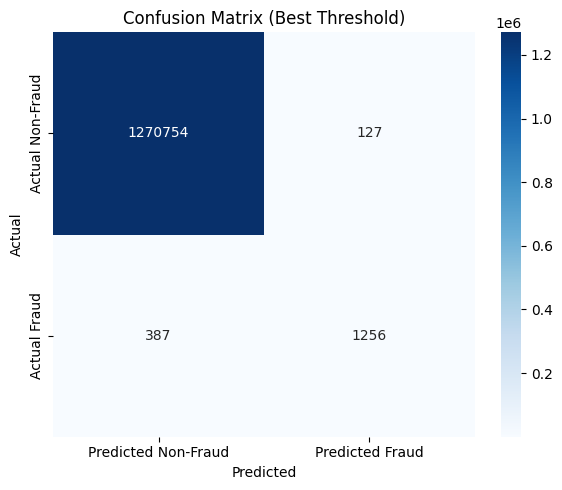

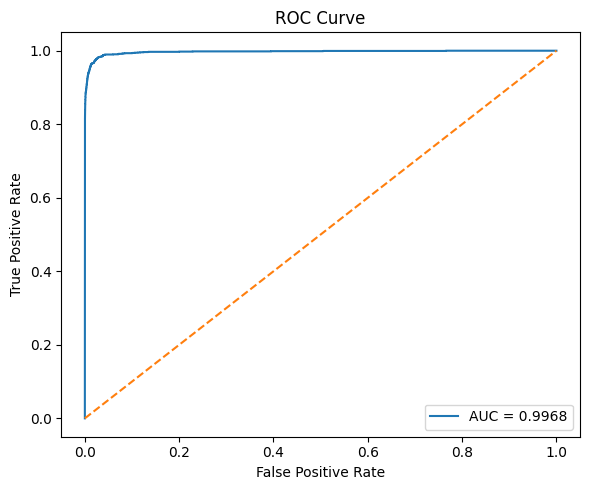

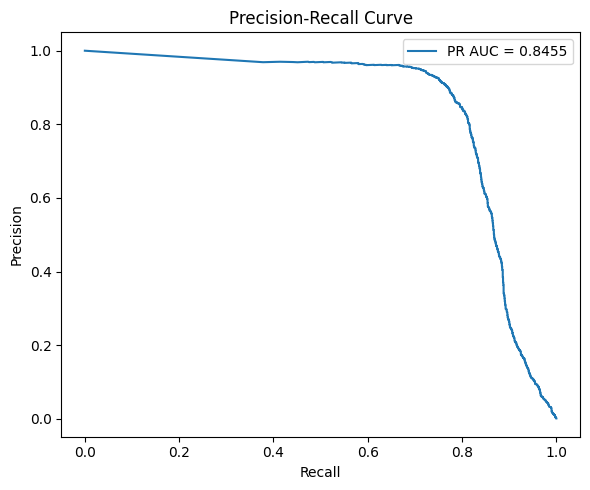


=== Final Metrics Summary (Best Threshold) ===
Accuracy  : 0.9996
Precision : 0.9082
Recall    : 0.7645
F1 Score  : 0.8301
ROC AUC   : 0.9968
PR AUC    : 0.8455


In [ ]:
# Visualization

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc as pr_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Confusion Matrix

cm = confusion_matrix(y_test, y_best)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-Fraud", "Predicted Fraud"],
    yticklabels=["Actual Non-Fraud", "Actual Fraud"]
)
plt.title("Confusion Matrix (Best Threshold)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()



# Precision-Recall Curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = pr_auc_score(recall_vals, precision_vals)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Final Metrics Summary

accuracy_val = accuracy_score(y_test, y_best)
precision_val = precision_score(y_test, y_best)
recall_val = recall_score(y_test, y_best)
f1_val = f1_score(y_test, y_best)

print("\n=== Final Metrics Summary (Best Threshold) ===")
print(f"Accuracy  : {accuracy_val:.4f}")
print(f"Precision : {precision_val:.4f}")
print(f"Recall    : {recall_val:.4f}")
print(f"F1 Score  : {f1_val:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"PR AUC    : {pr_auc:.4f}")

##Observations:

Threshold tuning significantly improved fraud precision while maintaining strong recall.

At the optimal threshold (~0.998), the model achieved:

- Fraud Precision: 91%

- Fraud Recall: 76%

- Fraud F1 Score: 0.83

False positives were substantially reduced (127 legitimate transactions incorrectly flagged).

1,256 fraudulent transactions were correctly detected.

387 fraud cases were missed, reflecting a controlled precision–recall trade-off.